# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan

- Nama: I Wayan Mulawarman Restumurti
- Email: iwayanrestumurti33@gmail.com
- Id Dicoding: iwayanrestu

## Persiapan

### Menyiapkan library yang dibutuhkan

In [262]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    roc_curve,
    auc
)
import joblib

### Menyiapkan data yang akan diguankan

In [263]:
df = pd.read_csv('data.csv', sep=';')
df

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


## Data Understanding

In [264]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [265]:
df.describe()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [266]:
df.isna().sum()

,0
Marital_status,0
Application_mode,0
Application_order,0
Course,0
Daytime_evening_attendance,0
Previous_qualification,0
Previous_qualification_grade,0
Nacionality,0
Mothers_qualification,0
Fathers_qualification,0


In [267]:
df.duplicated().sum()

np.int64(0)

In [268]:
df['Status'].value_counts()

,count
Status,
Graduate,2209
Dropout,1421
Enrolled,794


## Data Preparation / Preprocessing

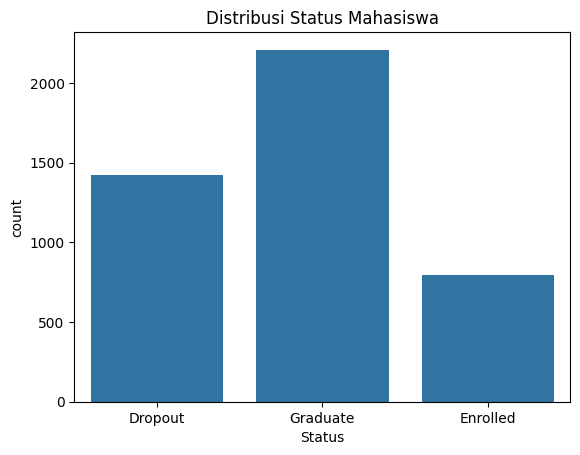

In [269]:
sns.countplot(x='Status', data=df)
plt.title('Distribusi Status Mahasiswa')
plt.show()

Insight

Jumlah mahasiswa yang Graduate adalah yang paling tinggi (lebih dari 2.000 mahasiswa). Ini menunjukkan bahwa mayoritas mahasiswa berhasil menyelesaikan studinya. Namun jumlah Dropout cukup signifikan (sekitar 1.400+ mahasiswa). Ini adalah angka yang cukup besar dan menjadi "red flag" bagi institusi. Rasio Dropout terhadap Graduate menunjukkan adanya kebocoran efisiensi pendidikan yang perlu dianalisis lebih lanjut faktor penyebabnya

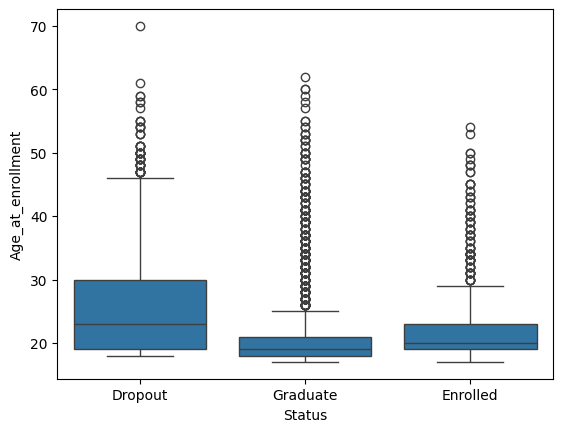

In [270]:
sns.boxplot(x='Status', y='Age_at_enrollment', data=df)
plt.show()

Insight
- Median usia untuk kelompok Dropout berada di angka yang lebih tinggi, yang menunjukkan bahwa mahasiswa yang mendaftar di usia lebih dewasa memiliki risiko putus sekolah yang lebih besar
- Kelompok Graduate memiliki rentang usia yang paling sempit dan terkonsentrasi di usia muda (sekitar 18 hingga 20 tahun). Hal ini mengindikasikan bahwa mahasiswa yang langsung melanjutkan pendidikan tepat waktu setelah lulus sekolah menengah memiliki peluang lebih tinggi untuk menyelesaikan studinya secara sukses

Variabel usia pendaftaran merupakan prediktor yang kuat dalam membedakan potensi Dropout. Mahasiswa yang mendaftar di atas usia 25 tahun dapat dikategorikan sebagai kelompok berisiko tinggi yang mungkin memerlukan dukungan tambahan karena kemungkinan adanya tanggung jawab lain di luar akademik seperti pekerjaan atau keluarga.

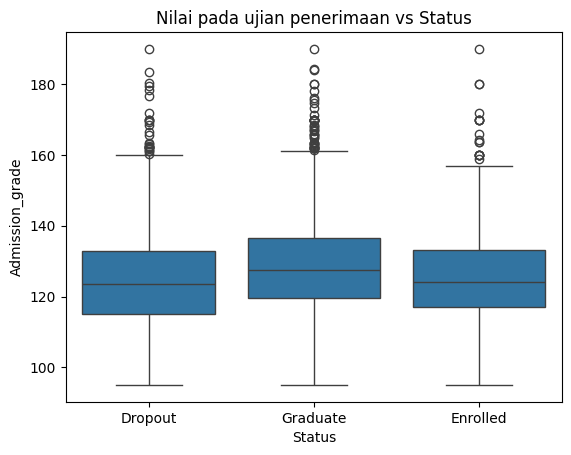

In [271]:
sns.boxplot(x='Status', y='Admission_grade', data=df)
plt.title('Nilai pada ujian penerimaan vs Status')
plt.show()

Insight
- Secara visual, median nilai masuk untuk ketiga kelompok (Graduate, Dropout, dan Enrolled) berada pada level yang sangat mirip, yaitu di kisaran angka 120 hingga 130. Hal ini menunjukkan bahwa nilai akademik saat pertama kali mendaftar bukan merupakan pembeda utama yang menentukan apakah seorang mahasiswa akan lulus atau putus sekolah


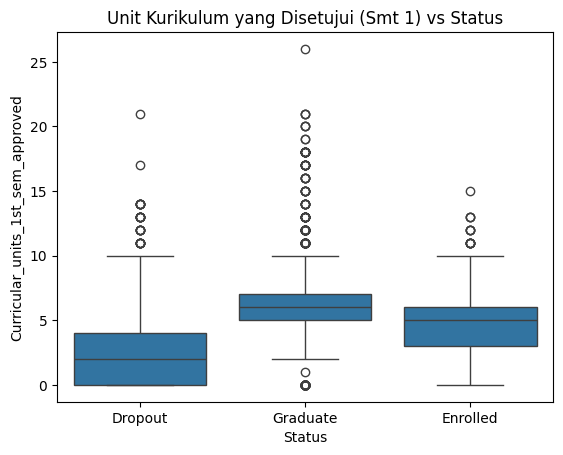

In [272]:
sns.boxplot(x='Status', y='Curricular_units_1st_sem_approved', data=df)
plt.title('Unit Kurikulum yang Disetujui (Smt 1) vs Status')
plt.show()

Insight
- Terdapat perbedaan median yang sangat mencolok antara mahasiswa yang Graduate dan Dropout. Mahasiswa yang lulus memiliki median nilai di kisaran 13 hingga 14, sedangkan kelompok Dropout memiliki median nilai 0. Hal ini menunjukkan bahwa kegagalan akademik di semester pertama merupakan indikator terkuat bagi mahasiswa untuk berhenti dari kuliah
- Banyaknya data pada angka 0 di kategori Dropout menunjukkan bahwa sebagian besar mahasiswa yang keluar kemungkinan besar sudah tidak mengikuti ujian atau tidak mendapatkan nilai sama sekali pada semester tersebut. Ini bisa menjadi sinyal bahwa keputusan untuk berhenti sering kali terjadi bahkan sebelum semester pertama berakhir

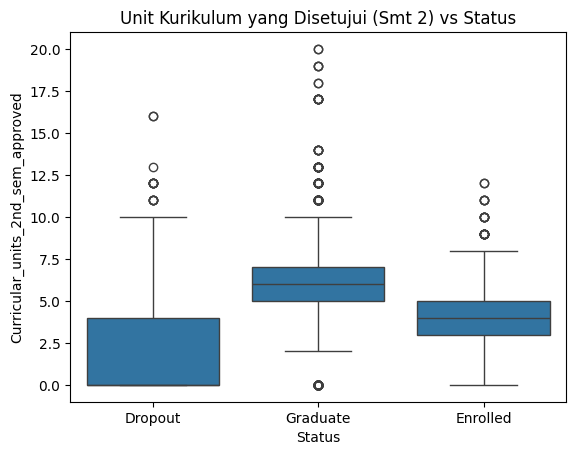

In [273]:
sns.boxplot(x='Status', y='Curricular_units_2nd_sem_approved', data=df)
plt.title('Unit Kurikulum yang Disetujui (Smt 2) vs Status')
plt.show()

Insight
- Terlihat perbedaan yang sangat ekstrem pada distribusi data. Kelompok Graduate memiliki median di angka 6, yang berarti mayoritas mahasiswa yang lulus berhasil melewati seluruh atau sebagian besar mata kuliah yang diambil. Sebaliknya, kelompok Dropout memiliki median di angka 0, yang menunjukkan bahwa sebagian besar mahasiswa yang putus sekolah tidak lulus satu pun mata kuliah di semester kedua
- Kotak (interquartile range) pada kelompok Dropout sangat pendek dan tertahan di angka bawah, sementara pada kelompok Graduate, kotak tersebut berada di angka yang jauh lebih tinggi. Ini membuktikan bahwa keberhasilan akademik di semester kedua adalah pemisah yang sangat jelas antara mereka yang mampu melanjutkan studi dan mereka yang terhenti.

Text(0.5, 1.0, 'Korelasi Faktor Kunci dengan Dropout')

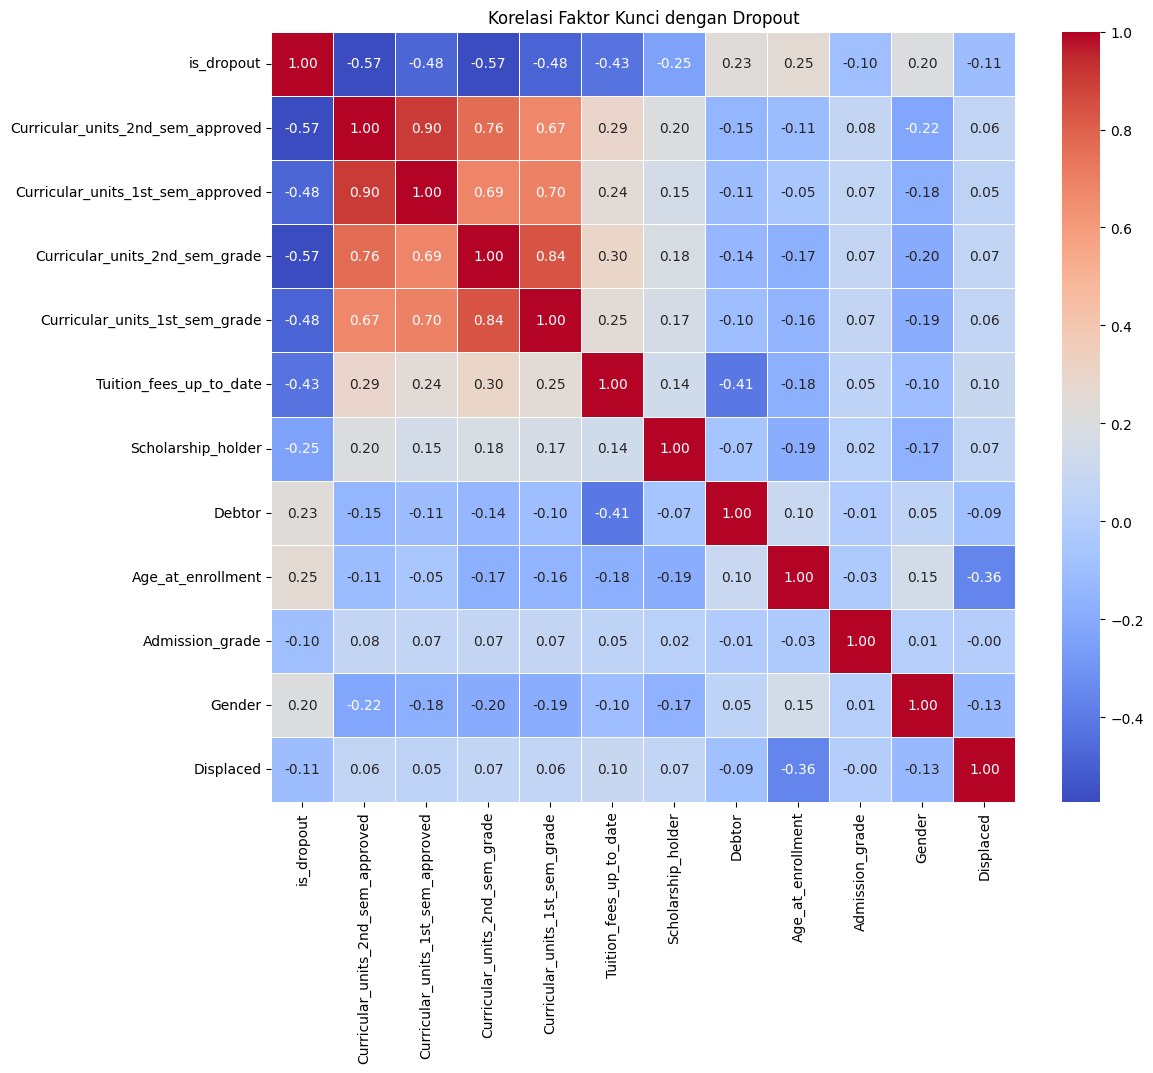

In [274]:
df_encoded = df.copy()
df_encoded['is_dropout'] = (df_encoded['Status'] == 'Dropout').astype(int)
# Select some likely relevant columns
cols_to_corr = [
    'is_dropout', 'Curricular_units_2nd_sem_approved', 'Curricular_units_1st_sem_approved',
    'Curricular_units_2nd_sem_grade', 'Curricular_units_1st_sem_grade',
    'Tuition_fees_up_to_date', 'Scholarship_holder', 'Debtor', 'Age_at_enrollment',
    'Admission_grade', 'Gender', 'Displaced'
]
corr_matrix = df_encoded[cols_to_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Korelasi Faktor Kunci dengan Dropout')

Insight
- Variabel Curricular_units_2nd_sem_approved dan Curricular_units_2nd_sem_grade menunjukkan warna yang paling gelap dan angka korelasi yang paling tinggi terhadap status kelulusan. Hal ini mengonfirmasi bahwa performa di akhir tahun pertama adalah titik balik paling krusial bagi seorang mahasiswa. Keberhasilan di tahap ini memiliki korelasi positif yang sangat kuat dengan probabilitas kelulusan akhir.
- Terdapat korelasi positif yang sangat kuat antara unit yang disetujui di semester pertama dengan semester kedua. Pola ini menunjukkan bahwa mahasiswa yang memulai perkuliahan dengan baik cenderung mempertahankan momentum tersebut. Sebaliknya, kegagalan di semester awal hampir selalu berlanjut pada kegagalan di semester berikutnya, menciptakan efek domino yang berujung pada keputusan untuk berhenti kuliah

Seluruh data visual ini secara konsisten membuktikan bahwa variabel akademik pada tahun pertama, khususnya jumlah mata kuliah yang lulus di semester kedua, merupakan indikator utama yang paling menentukan apakah seorang mahasiswa akan bertahan atau putus sekolah

/tmp/ipykernel_14262/153971885.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No (Tidak Berhutang)', 'Yes (Berhutang)'])


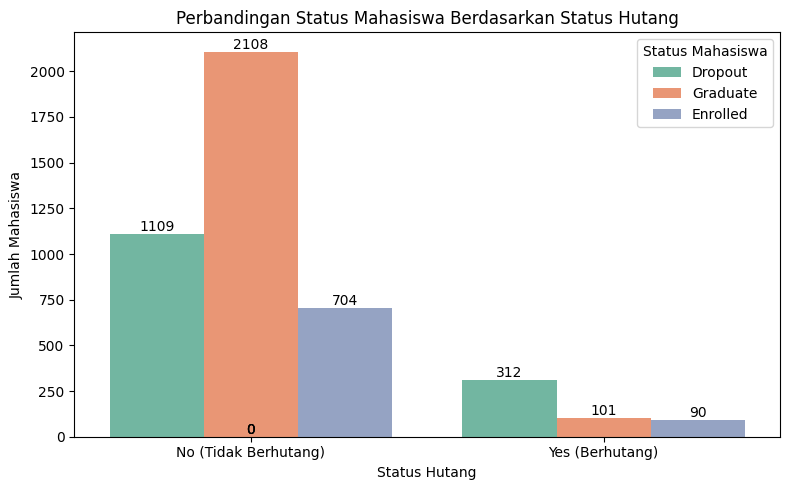

In [275]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='Debtor', hue='Status', data=df, palette='Set2')
ax.set_xticklabels(['No (Tidak Berhutang)', 'Yes (Berhutang)'])

plt.title('Perbandingan Status Mahasiswa Berdasarkan Status Hutang')
plt.xlabel('Status Hutang')
plt.ylabel('Jumlah Mahasiswa')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.legend(title='Status Mahasiswa')
plt.tight_layout()
plt.show()

Insight
- Grafik menunjukkan perbedaan yang sangat kontras pada kelompok Dropout. Sebagian besar mahasiswa yang putus sekolah memiliki status pembayaran yang tidak lancar (nilai 0). Fenomena ini mengindikasikan bahwa kendala finansial yang berujung pada tunggakan biaya kuliah memiliki korelasi yang sangat kuat dengan keputusan mahasiswa untuk berhenti dari pendidikannya.
- Pada kelompok Graduate, hampir seluruh mahasiswa memiliki status pembayaran yang lancar (nilai 1). Hal ini menunjukkan bahwa kepastian finansial merupakan fondasi dasar yang memungkinkan mahasiswa untuk fokus pada kegiatan akademik hingga mencapai kelulusan.
- Mahasiswa yang masih terdaftar (Enrolled) mayoritas memiliki pembayaran yang lancar, namun tetap ada sebagian kecil yang menunggak. Kelompok kecil yang menunggak ini merupakan kelompok yang paling rentan untuk berpindah status menjadi Dropout dalam waktu dekat jika tidak segera diberikan solusi bantuan keuangan atau skema cicilan

Status pembayaran biaya kuliah merupakan salah satu indikator deterministik yang paling nyata dalam memprediksi risiko dropout pada mahasiswa dalam dataset ini. Meskipun performa akademik sering kali menjadi alasan teknis, kondisi finansial yang tercermin dari kelancaran pembayaran SPP bertindak sebagai prasyarat utama agar mahasiswa dapat tetap bertahan dalam sistem pendidikan.

/tmp/ipykernel_14262/1695244408.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['No (Menunggak)', 'Yes (Lunas)'])


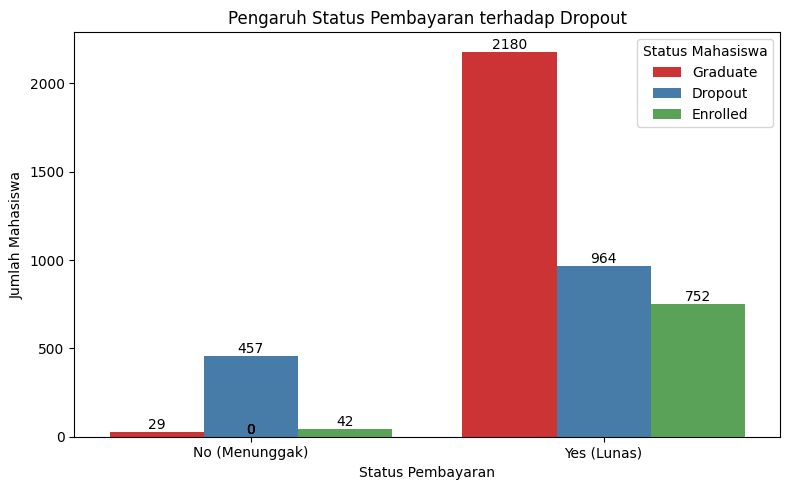

In [276]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='Tuition_fees_up_to_date', hue='Status', data=df, palette='Set1')

ax.set_xticklabels(['No (Menunggak)', 'Yes (Lunas)'])

plt.title('Pengaruh Status Pembayaran terhadap Dropout')
plt.xlabel('Status Pembayaran')
plt.ylabel('Jumlah Mahasiswa')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.legend(title='Status Mahasiswa')
plt.tight_layout()
plt.show()

Insight
- Pada kelompok yang Menunggak (No), jumlah mahasiswa yang Dropout (457) jauh lebih tinggi dibandingkan yang berhasil lulus/Graduate (hanya 29). Ini menunjukkan bahwa masalah finansial merupakan faktor risiko besar penyebab mahasiswa berhenti kuliah.

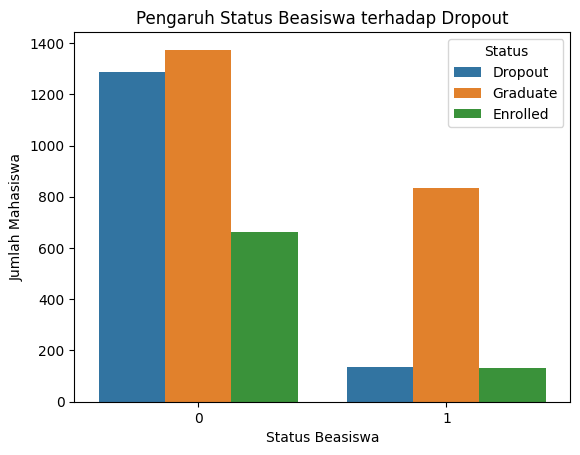

In [277]:
sns.countplot(x='Scholarship_holder', hue='Status', data=df)
plt.title('Pengaruh Status Beasiswa terhadap Dropout')
plt.xlabel('Status Beasiswa')
plt.ylabel('Jumlah Mahasiswa')
plt.show()

Insight
- Kelompok angka 0 menunjukkan mahasiswa yang tidak memiliki beasiswa. Jumlah mahasiswa di kelompok ini jauh lebih besar dibandingkan penerima beasiswa, namun angka putus sekolah (dropout) di sini sangat tinggi hingga hampir menyamai jumlah mahasiswa yang lulus (graduate)
- Kelompok angka 1 mewakili penerima beasiswa. Di sini terlihat perbedaan yang sangat mencolok karena jumlah mahasiswa yang lulus jauh melampaui jumlah yang putus sekolah. Hal ini menandakan bahwa bantuan finansial memberikan stabilitas yang luar biasa bagi mahasiswa untuk menyelesaikan studi mereka

Berdasarkan perbandingan kedua kelompok tersebut, dapat disimpulkan bahwa status kepemilikan beasiswa merupakan indikator utama yang secara signifikan menentukan apakah seorang mahasiswa akan bertahan hingga lulus atau justru mengalami dropout.

/tmp/ipykernel_14262/3843166335.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Female (Perempuan)', 'Male (Laki-laki)'])


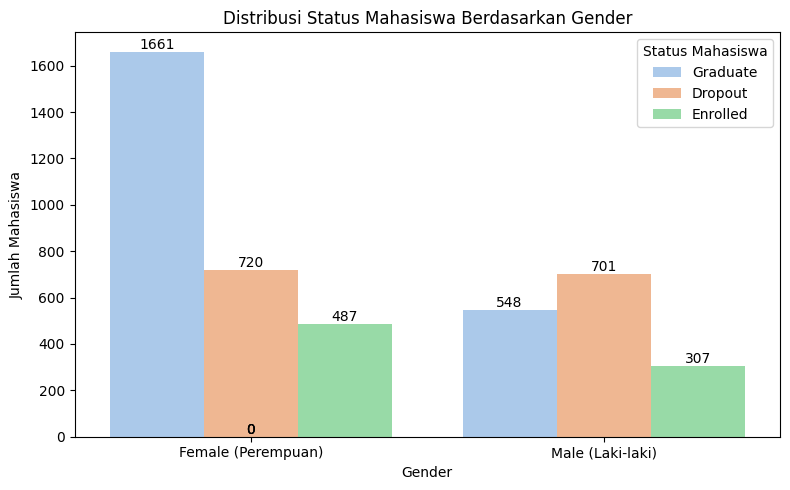

In [278]:
plt.figure(figsize=(8,5))

ax = sns.countplot(x='Gender', hue='Status', data=df, palette='pastel')

ax.set_xticklabels(['Female (Perempuan)', 'Male (Laki-laki)'])

plt.title('Distribusi Status Mahasiswa Berdasarkan Gender')
plt.xlabel('Gender')
plt.ylabel('Jumlah Mahasiswa')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.legend(title='Status Mahasiswa')
plt.tight_layout()
plt.show()

Insight
- Kelompok perempuan (Female) menunjukkan angka kelulusan (Graduate) yang sangat dominan yaitu mencapai 1661 orang. Angka ini jauh melampaui jumlah mahasiswi yang putus sekolah (Dropout) maupun yang masih terdaftar aktif. Hal ini mengindikasikan bahwa mahasiswi memiliki tingkat penyelesaian studi yang jauh lebih tinggi secara volume.
- Pada kelompok laki-laki (Male), jumlah mahasiswa yang mengalami Dropout yaitu 701 orang justru lebih besar daripada jumlah mahasiswa yang berhasil lulus yang hanya 548 orang. Fenomena ini menunjukkan adanya tantangan atau hambatan tertentu yang lebih berat dihadapi oleh mahasiswa laki-laki untuk mencapai kelulusan dibandingkan rekan perempuan mereka.

Berdasarkan data yang ditampilkan, dapat disimpulkan bahwa gender merupakan indikator utama yang secara signifikan mempengaruhi kecenderungan seorang mahasiswa untuk mengalami dropout atau berhasil lulus dalam sistem ini

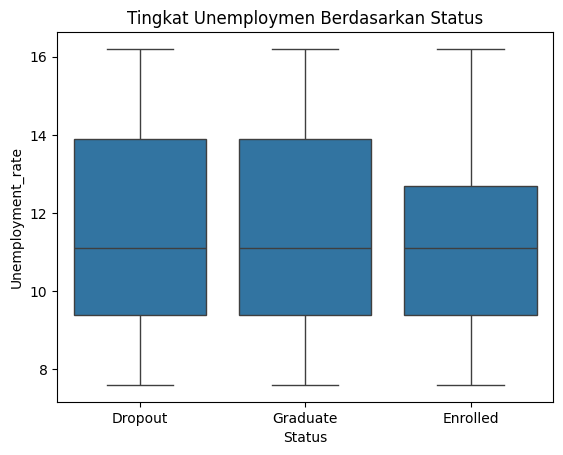

In [279]:
sns.boxplot(x='Status', y='Unemployment_rate', data=df)
plt.title('Tingkat Unemploymen Berdasarkan Status')
plt.show()


Insight
- Garis horizontal di dalam kotak biru menunjukkan nilai median atau nilai tengah dari tingkat pengangguran. Terlihat bahwa nilai median untuk ketiga kategori baik Dropout, Graduate, maupun Enrolled berada pada posisi yang hampir sejajar di angka sekitar 11 persen. Hal ini mengindikasikan bahwa secara rata-rata kondisi ekonomi terkait pengangguran tidak menunjukkan perbedaan yang mencolok di antara ketiga status tersebut.

Berdasarkan pengamatan visual terhadap data tersebut, dapat disimpulkan bahwa tingkat pengangguran bukan merupakan indikator utama yang secara langsung membedakan apakah seorang mahasiswa akan mengalami dropout atau berhasil lulus.

/tmp/ipykernel_14262/4257586745.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Status', y='GDP', data=df, palette='Set3')


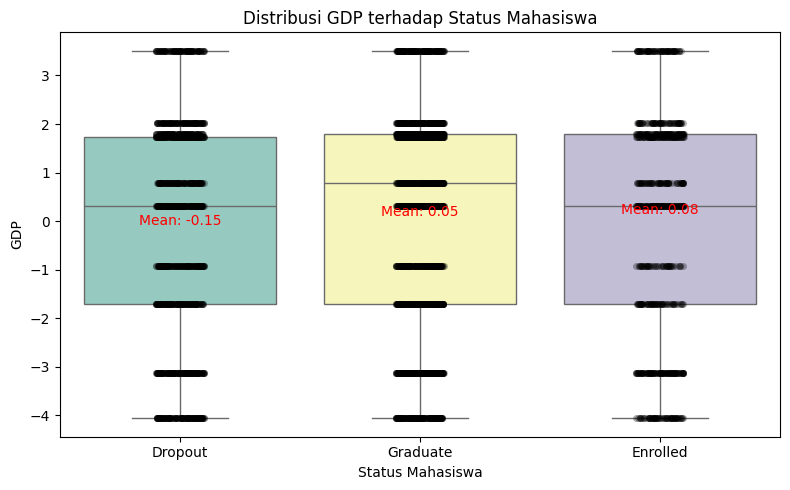

In [280]:
plt.figure(figsize=(8,5))

ax = sns.boxplot(x='Status', y='GDP', data=df, palette='Set3')
sns.stripplot(x='Status', y='GDP', data=df,
              color='black', alpha=0.3)

means = df.groupby('Status')['GDP'].mean()

for i, val in enumerate(means):
    plt.text(i, val, f'Mean: {val:.2f}',
             ha='center', va='bottom', color='red')

plt.title('Distribusi GDP terhadap Status Mahasiswa')
plt.xlabel('Status Mahasiswa')
plt.ylabel('GDP')

plt.tight_layout()
plt.show()

Insight
- Teks berwarna merah pada grafik menunjukkan nilai rata-rata (mean) untuk masing-masing kategori. Terlihat bahwa nilai rata-rata untuk Dropout (-0,15), Graduate (0,05), dan Enrolled (0,08) semuanya berada di kisaran angka yang sangat rendah dan mendekati nol. Hal ini mengindikasikan bahwa secara makro ekonomi, tidak ada perbedaan kondisi GDP yang ekstrem di antara ketiga kelompok tersebut.

Berdasarkan pengamatan pada distribusi data dan nilai rata-rata tersebut, dapat disimpulkan bahwa variabel GDP bukan merupakan indikator utama yang mempengaruhi apakah seorang mahasiswa akan mengalami dropout atau tidak

In [281]:
df.to_csv('data_clean.csv', index=False)

In [282]:
df['Status'] = df['Status'].map({
    'Dropout': 1,
    'Graduate': 0,
    'Enrolled': 0
})

## Modeling

In [283]:
X = df.drop('Status', axis=1)
y = df['Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [284]:
models = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000))
    ]),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),
}

In [285]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "model": model,
        "y_pred": y_pred
    }

## Evaluation

In [286]:
comparison = []

for name, res in results.items():
    print(f"\n=== {name} ===")

    acc = accuracy_score(y_test, res["y_pred"])
    f1 = f1_score(y_test, res["y_pred"], average='weighted')

    print("Accuracy:", acc)
    print("F1 Score:", f1)
    print("\nClassification Report:")
    print(classification_report(y_test, res["y_pred"]))

    comparison.append([name, acc, f1])


=== Logistic Regression ===
Accuracy: 0.8666666666666667
F1 Score: 0.863163312474023

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       569
           1       0.88      0.72      0.79       316

    accuracy                           0.87       885
   macro avg       0.87      0.83      0.85       885
weighted avg       0.87      0.87      0.86       885


=== Decision Tree ===
Accuracy: 0.7819209039548023
F1 Score: 0.7805117137237849

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       569
           1       0.71      0.67      0.69       316

    accuracy                           0.78       885
   macro avg       0.76      0.76      0.76       885
weighted avg       0.78      0.78      0.78       885


=== Random Forest ===
Accuracy: 0.8564971751412429
F1 Score: 0.8521485473136476

Classification Report:
              precision   

In [287]:
comparison_df = pd.DataFrame(
    comparison, columns=["Model", "Accuracy", "F1 Score"]
)

print("\nPerbandingan Model:")
print(comparison_df)



Perbandingan Model:
                 Model  Accuracy  F1 Score
0  Logistic Regression  0.866667  0.863163
1        Decision Tree  0.781921  0.780512
2        Random Forest  0.856497  0.852149


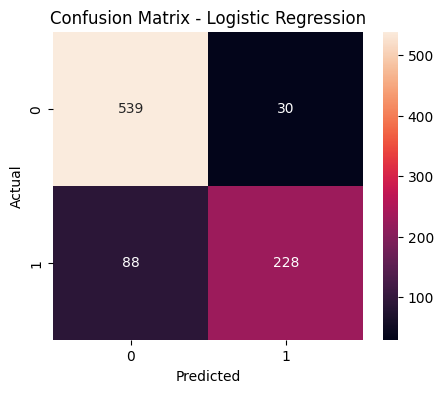

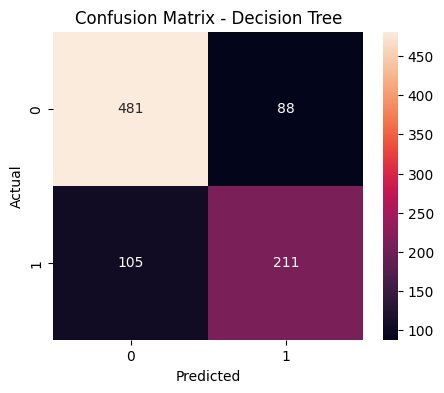

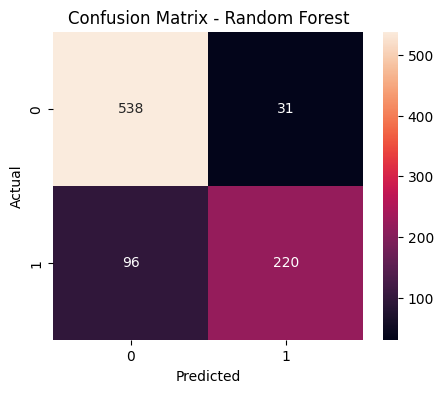

In [288]:
for name, res in results.items():
    cm = confusion_matrix(y_test, res["y_pred"])

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()


In [289]:
best_model = results["Logistic Regression"]["model"]
joblib.dump(best_model, 'model_dropout.pkl')

['model_dropout.pkl']

In [290]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

## Pemilihan Model Terbaik

Berdasarkan hasil evaluasi, model Logistic Regression dipilih sebagai model terbaik.

Model ini memiliki:
- Accuracy tertinggi sebesar 0.87
- F1-score tertinggi sebesar 0.86
- Recall untuk kelas dropout sebesar 0.72, yang merupakan yang tertinggi dibandingkan model lain

Hal ini menunjukkan bahwa Logistic Regression memiliki kemampuan terbaik dalam mendeteksi mahasiswa yang berpotensi dropout.

Meskipun demikian, nilai recall yang masih berada di sekitar 0.72 menunjukkan bahwa masih terdapat mahasiswa dropout yang belum terdeteksi, sehingga perlu adanya peningkatan model di masa depan.